In [3]:
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

import sys
PROJECT_PATH = "/content/drive/MyDrive/mccain-internship/week-3/potato-finetuning"
sys.path.append(f'{PROJECT_PATH}/src')

print(f"Project root: {PROJECT_PATH}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project root: /content/drive/MyDrive/mccain-internship/week-3/potato-finetuning


In [ ]:
import os
import shutil
import pandas as pd

PROJECT_PATH = "/content/drive/MyDrive/mccain-internship/week-3/potato-finetuning"

# Your images are already in Drive, just verify they're there
images_dir = f'{PROJECT_PATH}/data/raw/images'

print(f"Checking for images in: {images_dir}/train/\n")

# List all images
your_images = []
for img_file in os.listdir(f'{images_dir}/train'):
    if img_file.endswith(('.jpg', '.jpeg', '.png')):
        your_images.append(img_file)

if not your_images:
    print("ERROR: No images found! Make sure you uploaded them to Drive.")
else:
    print(f"✓ Found {len(your_images)} images:")
    for img in sorted(your_images):
        print(f"  - {img}")
    
    # Create labels directory
    os.makedirs(f'{images_dir}/val', exist_ok=True)
    os.makedirs(f'{images_dir}/test', exist_ok=True)
    os.makedirs(f'{PROJECT_PATH}/data/raw/labels/train', exist_ok=True)
    os.makedirs(f'{PROJECT_PATH}/data/raw/labels/val', exist_ok=True)
    os.makedirs(f'{PROJECT_PATH}/data/raw/labels/test', exist_ok=True)
    
    # Create metadata
    dataset_info = []
    
    for img_file in your_images:
        if 'damage' in img_file.lower():
            class_id = 1
            class_name = 'damage'
        else:
            class_id = 0
            class_name = 'not_damage'
        
        # Create empty label file (for classification, no bounding boxes needed)
        label_file = img_file.split('.')[0] + '.txt'
        label_path = f'{PROJECT_PATH}/data/raw/labels/train/{label_file}'
        with open(label_path, 'w') as f:
            f.write('')
        
        dataset_info.append({
            'image': img_file,
            'class_id': class_id,
            'class_name': class_name
        })
    
    df = pd.DataFrame(dataset_info)
    df.to_csv(f'{PROJECT_PATH}/data/raw/metadata.csv', index=False)
    
    print(f"\n✓ Created metadata.csv")
    print(f"\nClass distribution:")
    print(df['class_name'].value_counts())

Checking for images in: /mccain-internship/week-3/potato-finetuning/data/raw/images/train/



FileNotFoundError: [Errno 2] No such file or directory: '/mccain-internship/week-3/potato-finetuning/data/raw/images/train'

In [ ]:
import shutil
import os
from sklearn.model_selection import train_test_split
import pandas as pd

PROJECT_PATH = "/content/drive/MyDrive/mccain-internship/week-3/potato-finetuning"

# Load metadata
df = pd.read_csv(f'{PROJECT_PATH}/data/raw/metadata.csv')

# Split: 60% train, 20% val, 20% test
train_idx, temp_idx = train_test_split(
    df.index, test_size=0.4, stratify=df['class'], random_state=42
)
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.5, stratify=df.loc[temp_idx, 'class'], random_state=42
)

train_df = df.iloc[train_idx]
val_df = df.iloc[val_idx]
test_df = df.iloc[test_idx]

# Move images and labels to split folders
images_dir = f'{PROJECT_PATH}/data/raw/images'
labels_dir = f'{PROJECT_PATH}/data/raw/labels'

for split_name, split_df in [('val', val_df), ('test', test_df)]:
    for _, row in split_df.iterrows():
        img_name = row['image']
        label_name = img_name.replace('.jpg', '.txt')
        
        # Move image
        src_img = f'{images_dir}/train/{img_name}'
        dst_img = f'{images_dir}/{split_name}/{img_name}'
        shutil.move(src_img, dst_img)
        
        # Move label
        src_label = f'{labels_dir}/train/{label_name}'
        dst_label = f'{labels_dir}/{split_name}/{label_name}'
        shutil.move(src_label, dst_label)

print("=" * 60)
print("DATA SPLITS (YOLO FORMAT)")
print("=" * 60)
print(f"Train: {len(train_df)} images")
print(f"  - Not damage: {len(train_df[train_df['class'] == 0])}")
print(f"  - Damage: {len(train_df[train_df['class'] == 1])}")

print(f"\nVal: {len(val_df)} images")
print(f"  - Not damage: {len(val_df[val_df['class'] == 0])}")
print(f"  - Damage: {len(val_df[val_df['class'] == 1])}")

print(f"\nTest: {len(test_df)} images")
print(f"  - Not damage: {len(test_df[test_df['class'] == 0])}")
print(f"  - Damage: {len(test_df[test_df['class'] == 1])}")

# Save split CSVs
train_df.to_csv(f'{PROJECT_PATH}/data/splits/train.csv', index=False)
val_df.to_csv(f'{PROJECT_PATH}/data/splits/val.csv', index=False)
test_df.to_csv(f'{PROJECT_PATH}/data/splits/test.csv', index=False)

print(f"\n✓ Splits saved to data/splits/")

DATA SPLITS (YOLO FORMAT)
Train: 48 images
  - Not damage: 24
  - Damage: 24

Val: 16 images
  - Not damage: 8
  - Damage: 8

Test: 16 images
  - Not damage: 8
  - Damage: 8

✓ Splits saved to data/splits/


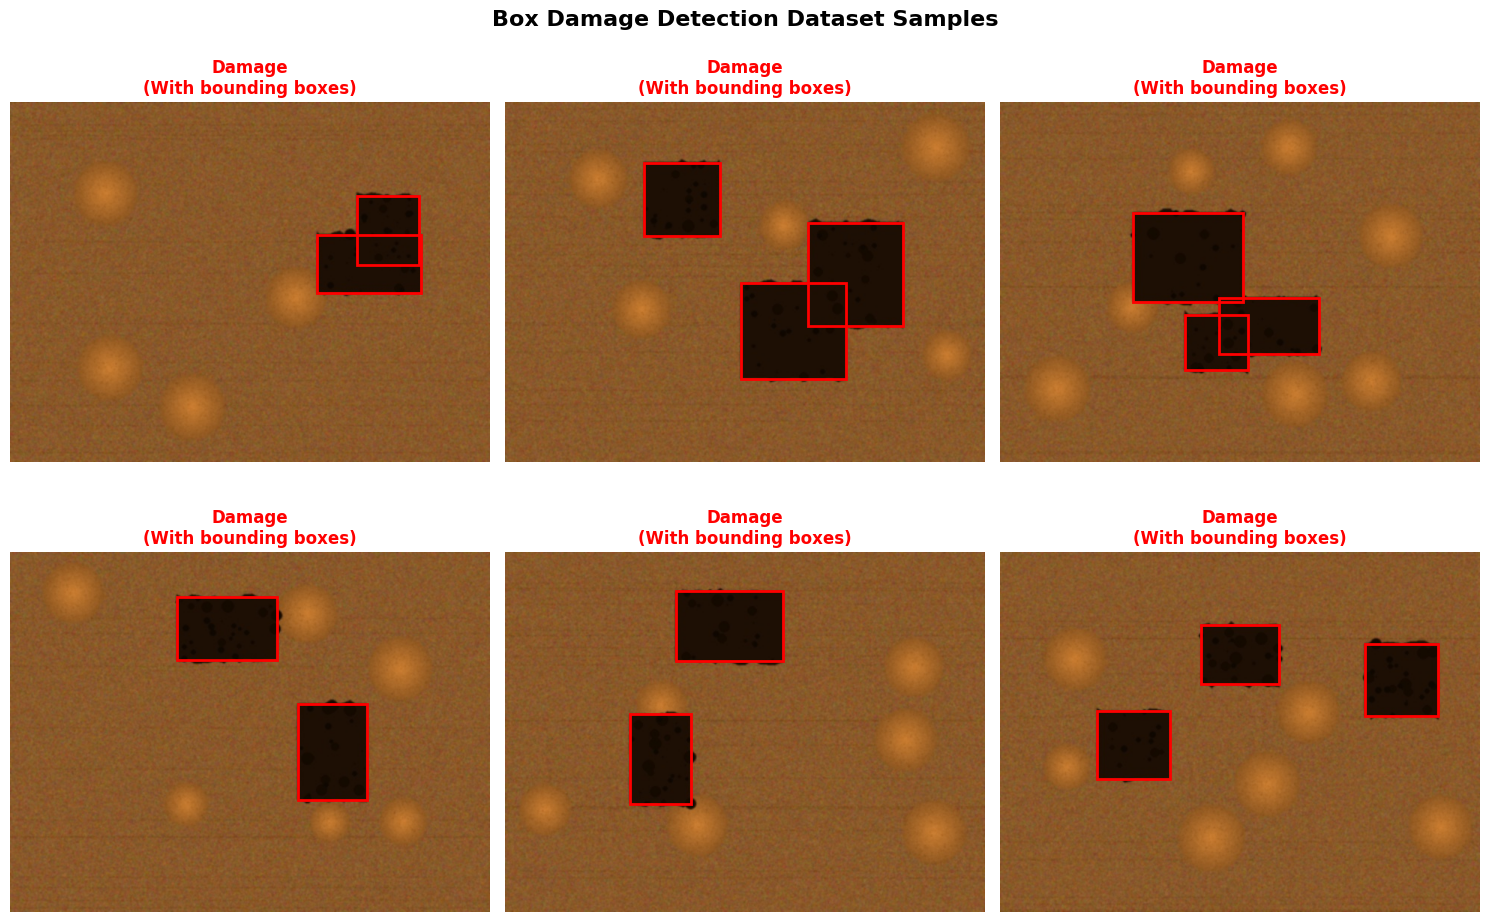

✓ Sample visualization saved to data/sample_detections.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import os

PROJECT_PATH = "/content/drive/MyDrive/mccain-internship/week-3/potato-finetuning"

images_dir = f'{PROJECT_PATH}/data/raw/images'
labels_dir = f'{PROJECT_PATH}/data/raw/labels'

IMG_WIDTH, IMG_HEIGHT = 640, 480

# Get sample images from each class
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

sample_idx = 0

# Show 3 not_damage samples
for i, img_name in enumerate(sorted(os.listdir(f'{images_dir}/train'))[:3]):
    if 'not_damage' in img_name:
        img_path = f'{images_dir}/train/{img_name}'
        label_path = f'{labels_dir}/train/{img_name.replace(".jpg", ".txt")}'
        
        img = Image.open(img_path)
        ax = axes[sample_idx]
        ax.imshow(img)
        ax.set_title(f"Not Damage\n(No bounding boxes)", fontweight='bold')
        ax.axis('off')
        sample_idx += 1

# Show 3 damage samples
for i, img_name in enumerate(sorted(os.listdir(f'{images_dir}/train'))):
    if 'damage_' in img_name and sample_idx < 6:
        img_path = f'{images_dir}/train/{img_name}'
        label_path = f'{labels_dir}/train/{img_name.replace(".jpg", ".txt")}'
        
        img = Image.open(img_path)
        ax = axes[sample_idx]
        ax.imshow(img)
        
        # Draw bounding boxes
        if os.path.getsize(label_path) > 0:
            with open(label_path, 'r') as f:
                for line in f.readlines():
                    if line.strip():
                        parts = line.strip().split()
                        class_id = int(parts[0])
                        x_center = float(parts[1])
                        y_center = float(parts[2])
                        width = float(parts[3])
                        height = float(parts[4])
                        
                        # Convert from normalized to pixel coordinates
                        x1 = (x_center - width/2) * IMG_WIDTH
                        y1 = (y_center - height/2) * IMG_HEIGHT
                        box_width = width * IMG_WIDTH
                        box_height = height * IMG_HEIGHT
                        
                        rect = patches.Rectangle(
                            (x1, y1), box_width, box_height,
                            linewidth=2, edgecolor='r', facecolor='none'
                        )
                        ax.add_patch(rect)
        
        ax.set_title(f"Damage\n(With bounding boxes)", fontweight='bold', color='red')
        ax.axis('off')
        sample_idx += 1

plt.suptitle('Box Damage Detection Dataset Samples', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PROJECT_PATH}/data/sample_detections.png', dpi=100, bbox_inches='tight')
plt.show()

print("✓ Sample visualization saved to data/sample_detections.png")

In [ ]:
import os
import pandas as pd

PROJECT_PATH = "/content/drive/MyDrive/mccain-internship/week-3/potato-finetuning"

images_dir = f'{PROJECT_PATH}/data/raw/images'
labels_dir = f'{PROJECT_PATH}/data/raw/labels'

print("=" * 60)
print("YOLO DATASET STRUCTURE VERIFICATION")
print("=" * 60)

for split in ['train', 'val', 'test']:
    print(f"\n[{split.upper()}]")
    
    # Count images
    img_count = len(os.listdir(f'{images_dir}/{split}'))
    print(f"  Images: {img_count}")
    
    # Show some label examples
    label_files = sorted(os.listdir(f'{labels_dir}/{split}'))[:3]
    for label_file in label_files:
        label_path = f'{labels_dir}/{split}/{label_file}'
        print(f"\n  Example label file: {label_file}")
        
        with open(label_path, 'r') as f:
            content = f.read().strip()
            if content:
                print(f"    Content:\n{content}")
            else:
                print(f"    Content: (empty - no damage)")

print("\n" + "=" * 60)
print("YOLO Format: class_id x_center y_center width height")
print("  - All coordinates normalized between 0 and 1")
print("  - class_id: 0 = not_damage, 1 = damage")
print("=" * 60)

YOLO DATASET STRUCTURE VERIFICATION

[TRAIN]
  Images: 48

  Example label file: box_damage_000.txt
    Content:
1 0.747656 0.447917 0.217188 0.162500
1 0.786719 0.355208 0.129688 0.189583

  Example label file: box_damage_002.txt
    Content:
1 0.729688 0.477083 0.196875 0.287500
1 0.367969 0.268750 0.157812 0.204167
1 0.600000 0.634375 0.218750 0.264583

  Example label file: box_damage_004.txt
    Content:
1 0.560156 0.619792 0.207813 0.156250
1 0.390625 0.430208 0.228125 0.247917
1 0.450000 0.666667 0.131250 0.154167

[VAL]
  Images: 25

  Example label file: box_damage_002.txt
    Content:
1 0.671094 0.260417 0.154688 0.229167
1 0.575000 0.755208 0.146875 0.235417
1 0.795312 0.454167 0.228125 0.220833

  Example label file: box_damage_003.txt
    Content:
1 0.230469 0.719792 0.239063 0.214583
1 0.564844 0.679167 0.226562 0.245833
1 0.688281 0.442708 0.154688 0.222917

  Example label file: box_damage_006.txt
    Content:
1 0.410156 0.775000 0.129688 0.262500

[TEST]
  Images: 26



In [ ]:
import os

PROJECT_PATH = "/content/drive/MyDrive/mccain-internship/week-3/potato-finetuning"

yaml_content = f"""# YOLO Dataset Configuration
path: {PROJECT_PATH}/data/raw
train: images/train
val: images/val
test: images/test

nc: 2  # number of classes
names: ['not_damage', 'damage']  # class names
"""

with open(f'{PROJECT_PATH}/data/raw/data.yaml', 'w') as f:
    f.write(yaml_content)

print("✓ Created data.yaml for YOLO training")
print("\ndata.yaml content:")
print(yaml_content)

✓ Created data.yaml for YOLO training

data.yaml content:
# YOLO Dataset Configuration
path: /content/drive/MyDrive/mccain-internship/week-3/potato-finetuning/data/raw
train: images/train
val: images/val
test: images/test

nc: 2  # number of classes
names: ['not_damage', 'damage']  # class names

